Read historical data from solcast to train baseline data. then use solcast current data and predict baseline to analyse.

In [1]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sqlalchemy import create_engine

In [2]:
def compute_diff(series):
    series_diff = series.diff()
    return series_diff

def handle_outliers(series):
    threshold = np.nanquantile(series, 0.999)
    return series.where((series <= threshold) & (series >= 0), np.nan)

def adjust_year(x, target_year=2021):
    try:
        return x.replace(year=target_year)
    except ValueError:  # February 29th does not exist in a non-leap year
        return x.replace(year=target_year, day=28)

In [3]:
# Database details
server = '23.101.237.42'
database = 'leap'
username = 'sa'
password = 'NjOzAi^GpU!!'

# Create the connection URL for the SQLAlchemy engine
# Note: We use urllib.parse.quote_plus to ensure special characters in the password (or username) are correctly formatted
connection_url = f"mssql+pyodbc:///?odbc_connect=" + urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};TrustServerCertificate=yes"
)

solcast historical data as for the baseline.
 solsite simulation db have solar company data


Load Historical data to learn models for each meter.

In [4]:
bun_sol_df = pd.read_csv('data/bundoora_solcast.csv')
bun_sol_df['campus'] = ['BUNDOORA'] * len(bun_sol_df)

wod_sol_df = pd.read_csv('data/wodonga_solcast.csv')
wod_sol_df['campus'] = ['WODONGA'] * len(bun_sol_df)

ben_sol_df = pd.read_csv('data/bendigo_solcast.csv')
ben_sol_df['campus'] = ['BENDIGO'] * len(bun_sol_df)

mil_sol_df = pd.read_csv('data/mildura_solcast.csv')
mil_sol_df['campus'] = ['MILDURA'] * len(bun_sol_df)

she_sol_df = pd.read_csv('data/shepparton_solcast.csv')
she_sol_df['campus'] = ['SHEPPARTON'] * len(bun_sol_df)

solcast_hist_df = pd.concat([bun_sol_df, wod_sol_df, ben_sol_df, mil_sol_df, she_sol_df])
solcast_hist_df['timestamp'] = pd.to_datetime(solcast_hist_df['period_end']).dt.strftime('%Y-%m-%d %H:%M:%S')
solcast_hist_df['timestamp'] = pd.to_datetime(solcast_hist_df['timestamp'])
solcast_hist_df.drop(columns=['clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'period', 'period_end'], inplace=True)


Load new data that are not included in above files.

In [5]:
from azure.storage.blob import BlobServiceClient
from io import StringIO

sas_token = "UmQIm94uLMGZkl8vOie0B1omByZBzJmP6tNodMe9HVHlgWAgprw2OX62wXCZqmJ4jAH04IBlfM5xNukhc3x9rQ=="
container_name = "solar-forecasts-solcast"

blob_service_client = BlobServiceClient(account_url="https://leapdata.blob.core.windows.net", credential=sas_token)
container_client = blob_service_client.get_container_client(container_name)

csv_files = [blob.name for blob in container_client.list_blobs() if "live" in blob.name and blob.name.endswith(".csv")]

dataframes = []
for file in csv_files:
    blob_client = container_client.get_blob_client(file)
    csv_data = blob_client.download_blob().content_as_text()
    temp_df = pd.read_csv(StringIO(csv_data))
    temp_df['source_file'] = file  # Add source file column to track file origins
    dataframes.append(temp_df)

solcast_live_df = pd.concat(dataframes)
solcast_live_df['accessed_on'] = pd.to_datetime(solcast_live_df['accessed_on'])
solcast_live_df['timestamp'] = pd.to_datetime(solcast_live_df['timestamp'])
solcast_live_df = solcast_live_df.sort_values(by='accessed_on').drop_duplicates(subset=['timestamp', 'campus'], keep='last')
# solcast_live_df = solcast_live_df.sort_values(by='timestamp')
solcast_live_df = solcast_live_df[solcast_live_df['timestamp'] > '2024-07-13 00:00:00']   # university wise .csv files have only data until july 13
solcast_live_df = solcast_live_df.sort_values(by='timestamp')
solcast_live_df.drop(columns=['accessed_on', 'source_file', 'timestamp_utc'], inplace=True)

In [6]:
solcast_live_df
solcast_df = pd.concat([solcast_hist_df, solcast_live_df])


solcast_df.to_csv("data/solcast_real.csv")

In [7]:
from azure.storage.blob import BlobServiceClient
from io import StringIO

sas_token = "UmQIm94uLMGZkl8vOie0B1omByZBzJmP6tNodMe9HVHlgWAgprw2OX62wXCZqmJ4jAH04IBlfM5xNukhc3x9rQ=="
container_name = "solar-forecasts-solcast"

blob_service_client = BlobServiceClient(account_url="https://leapdata.blob.core.windows.net", credential=sas_token)
container_client = blob_service_client.get_container_client(container_name)

csv_files = [blob.name for blob in container_client.list_blobs() if "forecast" in blob.name and blob.name.endswith(".csv")]

dataframes = []
for file in csv_files:
    blob_client = container_client.get_blob_client(file)
    csv_data = blob_client.download_blob().content_as_text()
    temp_df = pd.read_csv(StringIO(csv_data))
    temp_df['source_file'] = file  # Add source file column to track file origins
    dataframes.append(temp_df)

solcast_forecast_df = pd.concat(dataframes)
solcast_forecast_df['accessed_on'] = pd.to_datetime(solcast_forecast_df['accessed_on'])
solcast_forecast_df['timestamp'] = pd.to_datetime(solcast_forecast_df['timestamp'])
solcast_forecast_df = solcast_forecast_df.sort_values(by='accessed_on').drop_duplicates(subset=['timestamp', 'campus'], keep='last')
# solcast_live_df = solcast_live_df.sort_values(by='timestamp')
solcast_forecast_df = solcast_forecast_df[solcast_forecast_df['timestamp'] > '2025-08-15 00:00:00']   # university wise .csv files have only data until july 13
solcast_forecast_df = solcast_forecast_df.sort_values(by='timestamp')
solcast_forecast_df.drop(columns=['accessed_on', 'source_file', 'timestamp_utc'], inplace=True)

In [8]:
pd.unique(solcast_forecast_df['campus'])

array(['WODONGA', 'BUNDOORA'], dtype=object)

Merge hist data and live data into one file

In [9]:
solcast_forecast_df    # weather data of all the area by each 30 minutes, from 2021 to present
# solcast_live_df.to_csv('data/model_accuracy.csv', index=False)
solcast_forecast_df.to_csv("data/solcast_pred.csv")

Get All meter names

In [10]:
# Create an SQLAlchemy engine
engine = create_engine(connection_url)

# Use the engine to execute a query and load the result set into a DataFrame
query = "SELECT DISTINCT meter FROM [Leap].[dbo].[SolarSiteSimulation]"
meters_df = pd.read_sql_query(query, engine)
meters = meters_df['meter'].to_list()

# Close the engine connection
engine.dispose()

In [ ]:
# df_30 = pd.read_csv("data/SolarMeterReadings30min.csv")
# sol_real = pd.read_csv("data/solcast_real.csv")
# sol_pred = pd.read_csv("data/solcast_pred.csv")
# sol_pred = sol_pred[sol_pred["timestamp"] > list(df_30["timestamp"])[-1]]
# meters = pd.unique(df_30["meter"])

In [11]:
meters = list(set(meters_df['meter']))

campuses = []
for meter in meters:
    if('bun' in meter): campuses.append('BUNDOORA')
    elif('albury' in meter): campuses.append('WODONGA')
    elif('bendigo' in meter): campuses.append('BENDIGO')
    elif('mildura' in meter): campuses.append('MILDURA')
    elif('shepparton' in meter): campuses.append('SHEPPARTON')

Read power generation data from Solar site simulator table. Then train models for weather data and power generation.

In [12]:
acc_df = pd.read_csv('data/model_accuracy.csv')

## Training XGBoost models   -  Simulated model

In [ ]:
# Create an SQLAlchemy engine
engine = create_engine(connection_url)
    
first = True
for i in range(len(meters)):
    meter = meters[i]
    campus = campuses[i]
    print(f"Processing {meter}")
    meter_weather_df = solcast_df[solcast_df['campus'] == campus][['air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith', 'timestamp']]

    # try:
    # Use the engine to execute a query and load the result set into a DataFrame
    query = f"SELECT *, [grid_power] / 1000 AS grid_power_kWh FROM [Leap].[dbo].[SolarSiteSimulation] WHERE meter = '{meter}' ORDER BY timestamp"
    sim_df = pd.read_sql_query(query, engine)
    # print(sim_df)
    sim_df = pd.merge(sim_df, meter_weather_df, on='timestamp', how='left')

    # Select features and target variable
    features = ['global_horizontal_irradiance','air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith']
    target = 'grid_power_kWh'

    # Prepare the data
    X = sim_df[features].astype(float)
    y = sim_df[target].astype(float)

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the XGBoost regressor
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100)
    xgb_model.fit(X_train, y_train)

    # Predictions
    xgb_predictions = xgb_model.predict(X_test)

    # Evaluate the models___
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)

    print(f'{meter} RMSE: {xgb_rmse}')

    model_name = meter + '.pkl'
    filepath = os.path.join('models/simulated', model_name)
    joblib.dump(xgb_model, filepath)

    # Update accuracy csv
    acc_df.loc[acc_df['Meter']==meter, 'NEW RMSE'] = xgb_rmse
    acc_df.loc[acc_df['Meter']==meter, 'NEW MAE'] = xgb_mae

    print("")
# Close the engine connection
engine.dispose()
acc_df.to_csv('data/model_accuracy.csv', index=False)

Processing solar.albury-wodonga_admin#realenergyintotheload#kwh


## Load Real 30 min data

In [13]:
old_final_df = pd.read_csv("data\SolarMeterReadings30min_new.csv")
last_date = list(old_final_df['timestamp'])[-1]

print(last_date)

2025-08-11 14:30:00


In [14]:
# Create an SQLAlchemy engine
# engine = create_engine(connection_url)

# # Use the engine to execute a query and load the result set into a DataFrame
# query = "SELECT DISTINCT [MeterKeyString] FROM [Leap].[dbo].[SolarMeterReadings] WHERE [MeterKeyString] LIKE '%realenergyintotheload%'"
# meters_df = pd.read_sql_query(query, engine)
# meters = meters_df['MeterKeyString'].to_list()

# # Close the engine connection
# engine.dispose()


engine = create_engine(connection_url)

dfs = []  
for meter in meters:
    print(f"Processing {meter}")
    
    try:
        query = f"SELECT * FROM [SolarMeterReadings] WHERE [MeterKeyString] = '{meter}' AND [ReadingTimestamp] > '{last_date}'  ORDER BY ReadingTimestamp"
        df = pd.read_sql_query(query, engine)
        df.drop_duplicates(subset=['ReadingTimestamp'], inplace=True)
        df['MeterReading'] = df['MeterReading'].interpolate()
        df['Difference'] = df['MeterReading'].transform(compute_diff)
        df['meter_reading'] = df['Difference'].transform(handle_outliers)
        df['meter_reading'].interpolate(method='linear', inplace=True)
        # df['data_out'] = np.where(df['meter_reading'].isnull(), 1, 0)
        df['timestamp'] = pd.to_datetime(df['ReadingTimestamp'])

        df.set_index('timestamp', inplace=True)
        df = df.resample('30T').agg({'meter_reading': 'sum'})
        df.reset_index(inplace=True)
        
        df['meter'] = [meter] * len(df)
        dfs.append(df)
    except:
        print(f"{meter} failed")
# Close the engine connection

final_df = pd.concat(dfs)
final_df = pd.concat([old_final_df, final_df])
final_df.to_csv('data/SolarMeterReadings30min.csv', index=False)
engine.dispose()

Processing solar.bun_rlr#realenergyintotheload#kwh
Processing solar.bun_lwso#realenergyintotheload#kwh
Processing solar.shepparton#realenergyintotheload#kwh
Processing solar.bun_tlc#realenergyintotheload#kwh
Processing solar.bun_hs3#realenergyintotheload#kwh
Processing solar.bun_ltss_pv_lgcmeter#realenergyintotheload#kwh
Processing solar.bun_hu3#realenergyintotheload#kwh
Processing solar.bun_mb#realenergyintotheload#kwh
Processing solar.bun_rd2#realenergyintotheload#kwh
solar.bun_rd2#realenergyintotheload#kwh failed
Processing solar.bun_lims1#realenergyintotheload#kwh
Processing solar.bun_ps2#realenergyintotheload#kwh
Processing solar.bun_sw#realenergyintotheload#kwh
Processing solar.bun_hs2#realenergyintotheload#kwh
Processing solar.bun_cs1#realenergyintotheload#kwh
Processing solar.bun_wlt#realenergyintotheload#kwh
Processing solar.bun_mc#realenergyintotheload#kwh
Processing solar.bun_union#realenergyintotheload#kwh
Processing solar.bun_bg#realenergyintotheload#kwh
Processing solar.b

In [17]:
final_df_copy = final_df

In [19]:
final_df

,timestamp,meter_reading,meter
0,2020-01-08 08:30:00,0.0,solar.bun_hu3#realenergyintotheload#kwh
1,2020-01-08 09:00:00,0.0,solar.bun_hu3#realenergyintotheload#kwh
2,2020-01-08 09:30:00,0.0,solar.bun_hu3#realenergyintotheload#kwh
3,2020-01-08 10:00:00,0.0,solar.bun_hu3#realenergyintotheload#kwh
4,2020-01-08 10:30:00,0.0,solar.bun_hu3#realenergyintotheload#kwh
...,...,...,...
700,2025-08-26 04:30:00,0.0,solar.bun_hs1#realenergyintotheload#kwh
701,2025-08-26 05:00:00,0.0,solar.bun_hs1#realenergyintotheload#kwh
702,2025-08-26 05:30:00,0.0,solar.bun_hs1#realenergyintotheload#kwh
703,2025-08-26 06:00:00,0.0,solar.bun_hs1#realenergyintotheload#kwh


In [ ]:
import pandas as pd

# Copy & clean
dfh = final_df.copy()
dfh["timestamp"] = pd.to_datetime(dfh["timestamp"])
dfh["meter_reading"] = pd.to_numeric(dfh["meter_reading"], errors="coerce")

# Sort and index by time
dfh = dfh.sort_values(["meter", "timestamp"]).set_index("timestamp")

# Hourly sum per meter; right-closed bins labeled on the right
hourly = (
    dfh.groupby("meter")
       .resample("H", label="right", closed="right")["meter_reading"]
       .sum(min_count=1)  # if an hour has no points, leave NaN (not 0)
       .reset_index()
       .sort_values(["meter", "timestamp"])
)

print(hourly.head(20))


                                               meter           timestamp  \
0  solar.albury-wodonga_admin#realenergyintothelo... 2020-01-01 00:00:00   
1  solar.albury-wodonga_admin#realenergyintothelo... 2020-01-01 01:00:00   
2  solar.albury-wodonga_admin#realenergyintothelo... 2020-01-01 02:00:00   
3  solar.albury-wodonga_admin#realenergyintothelo... 2020-01-01 03:00:00   
4  solar.albury-wodonga_admin#realenergyintothelo... 2020-01-01 04:00:00   

   meter_reading  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  


In [26]:
final_df = hourly

## Train Reasl XGBoost models

In [27]:
def get_campus(meter_name: str) -> str:
    name = meter_name.lower()
    if "bun" in name:
        return "BUNDOORA"
    elif "albury" in name:
        return "WODONGA"
    elif "bendigo" in name:
        return "BENDIGO"
    elif "mildura" in name:
        return "MILDURA"
    elif "shepparton" in name:
        return "SHEPPARTON"
    else:
        return "UNKNOWN"


final_df["campus"] = final_df["meter"].apply(get_campus)

print(final_df.iloc[500000])

solcast_df['global_horizontal_irradiance'] = solcast_df['ghi']
solcast_forecast_df['global_horizontal_irradiance'] = solcast_forecast_df['ghi']
final_df['grid_power_kWh'] = final_df['meter_reading']
# final_df["timestamp"]     = pd.to_datetime(final_df["timestamp"], errors="coerce", utc=True)\
#                              .dt.tz_convert("UTC").dt.tz_localize(None)
# solcast_df["timestamp"] = pd.to_datetime(solcast_df["timestamp"], errors="coerce", utc=True)\
#                              .dt.tz_convert("UTC").dt.tz_localize(None)


final_df['timestamp'] = pd.to_datetime(final_df['timestamp'])

solcast_df['timestamp'] = pd.to_datetime(solcast_df['timestamp'])

meter            solar.bendigo_hillside_a2#realenergyintotheloa...
timestamp                                      2024-12-25 20:00:00
meter_reading                                             1.320312
campus                                                     BENDIGO
Name: 500000, dtype: object


In [28]:
meters = list(pd.unique(final_df["meter"]))
# campuses = list(pd.unique(final_df["campus"]))

# Train real models

In [31]:
# Create an SQLAlchemy engine
engine = create_engine(connection_url)
    
first = True
for i in range(len(meters)):
    meter = meters[i]
    # campus = campuses[i]
    # print(f"Processing {meter}, {campus}")
    
    # try:
    # Use the engine to execute a query and load the result set into a DataFrame
    # query = f"SELECT *, [grid_power] / 1000 AS grid_power_kWh FROM [Leap].[dbo].[SolarSiteSimulation] WHERE meter = '{meter}' ORDER BY timestamp"
    sim_df = final_df[final_df['meter'] == meter] #pd.read_sql_query(query, engine)
    
    campus = get_campus(meter)
    meter_weather_df = solcast_df[solcast_df['campus'] == campus][['global_horizontal_irradiance', 'air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith', 'timestamp']]


    sim_df = pd.merge(sim_df, meter_weather_df, on='timestamp', how='left')
    # print(sim_df.keys())
    # sim_df = pd.merge(sim_df, meter_weather_df, on='timestamp', how='left')

    # Select features and target variable
    features = ['global_horizontal_irradiance','air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith']
    target = 'grid_power_kWh'

    # Prepare the data
    X = sim_df[features].astype(float)
    print(len(X))
    y = sim_df[target].astype(float)
    print(len(y))
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the XGBoost regressor
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100)
    xgb_model.fit(X_train.iloc[-4000:], y_train.iloc[-4000:])

    # Predictions
    xgb_predictions = xgb_model.predict(X_test)

    # Evaluate the models___
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)

    print(f'{meter} RMSE: {xgb_rmse}')

    model_name = meter + '.pkl'
    filepath = os.path.join('models/real_h', model_name)
    joblib.dump(xgb_model, filepath)

    # Update accuracy csv
    acc_df.loc[acc_df['Meter']==meter, 'NEW RMSE'] = xgb_rmse
    acc_df.loc[acc_df['Meter']==meter, 'NEW MAE'] = xgb_mae

    print("")
# Close the engine connection
engine.dispose()
# acc_df.to_csv('data/model_accuracy.csv', index=False)

49192
49192
solar.albury-wodonga_admin#realenergyintotheload#kwh RMSE: 12.670400140960046

49192
49192
solar.albury-wodonga_carport#realenergyintotheload#kwh RMSE: 11.788793130374447

49192
49192
solar.albury-wodonga_health#realenergyintotheload#kwh RMSE: 21.212523479394278

49192
49192
solar.albury-wodonga_library#realenergyintotheload#kwh RMSE: 7.7210589279995165

40960
40960
solar.albury-wodonga_mh1#realenergyintotheload#kwh RMSE: 1.1006220296253872

40959
40959
solar.albury-wodonga_mh2#realenergyintotheload#kwh RMSE: 1.3001312986148394

39615
39615
solar.bendigo_as2_carpark#realenergyintotheload#kwh RMSE: 17.11427064779816

49191
49191
solar.bendigo_as2_hhs1-2#realenergyintotheload#kwh RMSE: 9.159549928407827

39615
39615
solar.bendigo_as2_ssc_roof#realenergyintotheload#kwh RMSE: 15.807361637213882

49192
49192
solar.bendigo_hillside_a1#realenergyintotheload#kwh RMSE: 2.8348573710583915

49191
49191
solar.bendigo_hillside_a2#realenergyintotheload#kwh RMSE: 1.2507675037065982

49192

In [78]:
# df = final_df # pd.read_csv('data/SolarMeterReadings30min.csv')
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# solcast_df['timestamp'] = pd.to_datetime(solcast_df['timestamp'])

# # df = pd.merge(df, solcast_df, on='timestamp', how='inner')
# solcast_df['global_horizontal_irradiance'] = solcast_df['ghi']

# Prediction

In [32]:
available_forecast = list(pd.unique(solcast_forecast_df["campus"]))
print(available_forecast)
solcast_forecast_df['global_horizontal_irradiance'] = solcast_forecast_df['ghi']

['WODONGA', 'BUNDOORA']


In [33]:
import os

folder_path = "models/simulated"

# List all items in the folder
simulted_meters = [x[:-4] for x in os.listdir(folder_path)]

folder_path = "models/real_h"

# List all items in the folder
real_meters = [x[:-4] for x in os.listdir(folder_path)]
common = list(set(simulted_meters) & set(real_meters))



In [43]:
# final_df[final_df['meter'] == "solar.bun_pw#realenergyintotheload#kwh"].tail(20)

In [46]:
# final_df_copy[final_df_copy['meter'] == "solar.bun_pw#realenergyintotheload#kwh"].tail(40)
solcast_forecast_df

,air_temp,albedo,azimuth,cloud_opacity,dewpoint_temp,dhi,dni,ghi,precipitable_water,precipitation_rate,...,snow_soiling_rooftop,snow_soiling_ground,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,zenith,timestamp,campus,global_horizontal_irradiance
340,5,0.17,178,5,3.9,0,0,0,9.9,0.0,...,0,0,90,107,3.3,2.1,159,2025-08-15 00:30:00,WODONGA,0
4,10,0.14,174,58,3.6,0,0,0,8.9,0.0,...,0,0,8,10,10.2,4.8,157,2025-08-15 00:30:00,BUNDOORA,0
341,5,0.17,-162,12,3.9,0,0,0,9.6,0.0,...,0,0,90,105,3.9,2.3,158,2025-08-15 01:00:00,WODONGA,0
5,10,0.14,-168,41,3.4,0,0,0,9.0,0.0,...,0,0,7,9,10.6,5.0,157,2025-08-15 01:00:00,BUNDOORA,0
6,10,0.14,-151,33,3.3,0,0,0,9.1,0.0,...,0,0,5,6,10.7,5.1,154,2025-08-15 01:30:00,BUNDOORA,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,3,0.17,-112,15,2.1,0,0,0,11.4,0.0,...,0,0,105,115,1.7,1.4,130,2025-09-02 03:30:00,WODONGA,0
334,6,0.14,-115,36,4.3,0,0,0,15.0,0.0,...,0,0,351,10,3.7,1.7,131,2025-09-02 03:30:00,BUNDOORA,0
335,6,0.14,-109,36,4.2,0,0,0,14.7,0.0,...,0,0,351,11,3.7,1.6,126,2025-09-02 04:00:00,BUNDOORA,0
671,3,0.17,-106,14,2.0,0,0,0,11.5,0.0,...,0,0,102,112,1.7,1.4,125,2025-09-02 04:00:00,WODONGA,0


In [ ]:
solcast_forecast_df_copy = solcast_forecast_df


# sol_df = solcast_forecast_df.copy()
# sol_df["timestamp"] = pd.to_datetime(sol_df["timestamp"])

# # Keep only exact hour stamps (…:00:00). Works for 30-min cadence (:00, :30).
# sol_df_hour = (
#     sol_df.loc[
#         (sol_df["timestamp"].dt.minute == 0) &
#         (sol_df["timestamp"].dt.second == 0) &
#         (sol_df["timestamp"].dt.microsecond == 0)
#     ]
#     .sort_values("timestamp")
#     .drop_duplicates(subset=["timestamp"])
# )

# solcast_forecast_df = sol_df_hour

In [51]:
solcast_forecast_df = solcast_forecast_df_copy

In [52]:
solcast_forecast_df.head(24)

,air_temp,albedo,azimuth,cloud_opacity,dewpoint_temp,dhi,dni,ghi,precipitable_water,precipitation_rate,...,snow_soiling_rooftop,snow_soiling_ground,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,zenith,timestamp,campus,global_horizontal_irradiance
340,5,0.17,178,5,3.9,0,0,0,9.9,0.0,...,0,0,90,107,3.3,2.1,159,2025-08-15 00:30:00,WODONGA,0
4,10,0.14,174,58,3.6,0,0,0,8.9,0.0,...,0,0,8,10,10.2,4.8,157,2025-08-15 00:30:00,BUNDOORA,0
341,5,0.17,-162,12,3.9,0,0,0,9.6,0.0,...,0,0,90,105,3.9,2.3,158,2025-08-15 01:00:00,WODONGA,0
5,10,0.14,-168,41,3.4,0,0,0,9.0,0.0,...,0,0,7,9,10.6,5.0,157,2025-08-15 01:00:00,BUNDOORA,0
6,10,0.14,-151,33,3.3,0,0,0,9.1,0.0,...,0,0,5,6,10.7,5.1,154,2025-08-15 01:30:00,BUNDOORA,0
342,5,0.17,-146,18,3.9,0,0,0,9.6,0.0,...,0,0,91,108,3.8,2.2,155,2025-08-15 01:30:00,WODONGA,0
343,5,0.17,-132,26,3.8,0,0,0,9.9,0.0,...,0,0,94,116,3.0,1.9,151,2025-08-15 02:00:00,WODONGA,0
7,10,0.14,-137,43,3.2,0,0,0,9.2,0.0,...,0,0,3,4,10.6,5.1,151,2025-08-15 02:00:00,BUNDOORA,0
344,5,0.17,-122,31,3.8,0,0,0,10.1,0.0,...,0,0,94,118,2.6,1.7,146,2025-08-15 02:30:00,WODONGA,0
8,10,0.14,-126,48,3.2,0,0,0,9.2,0.0,...,0,0,3,2,10.7,5.2,146,2025-08-15 02:30:00,BUNDOORA,0


0.9703725093562656


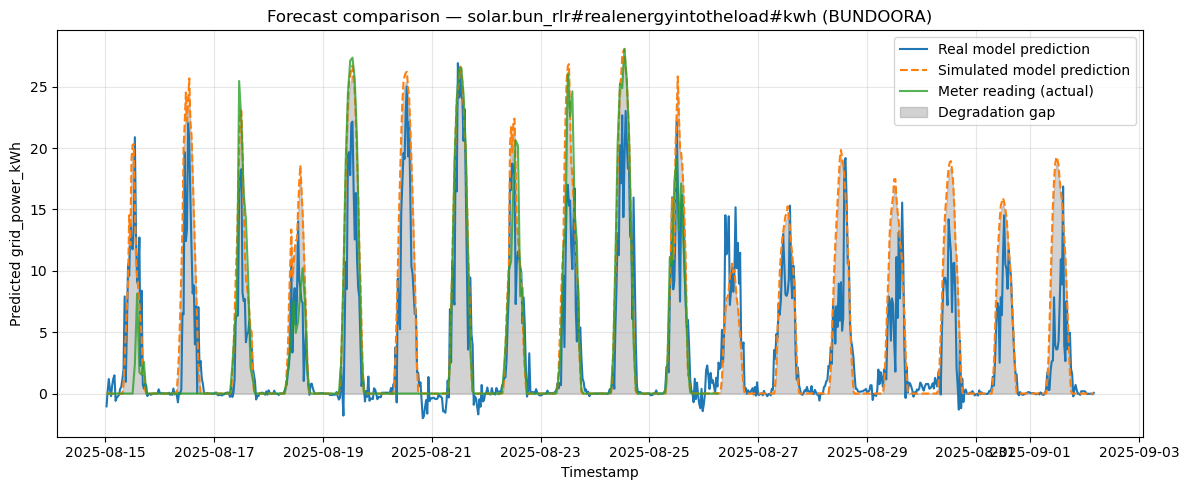

0.9703725093562656


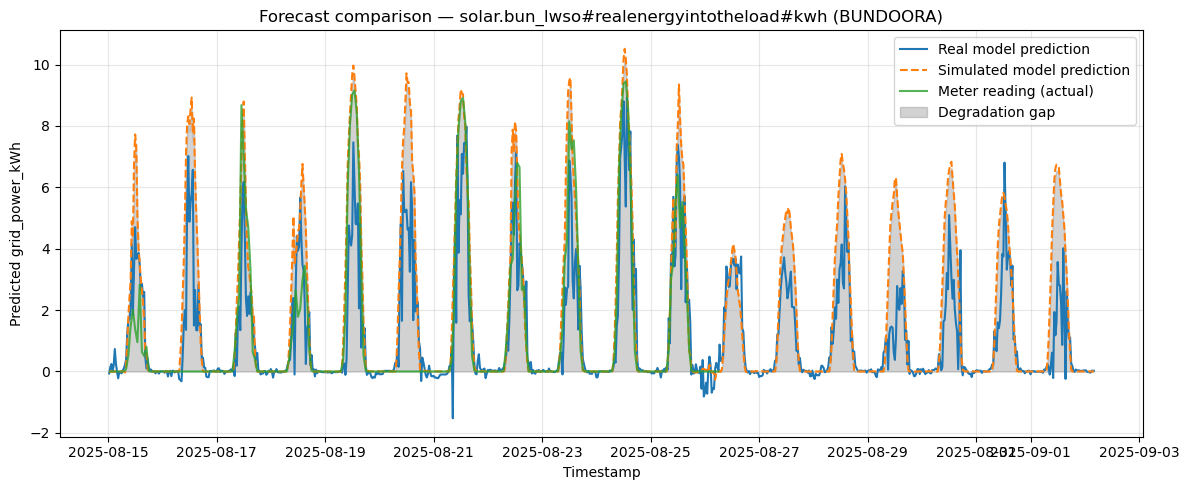

0.9703725093562656


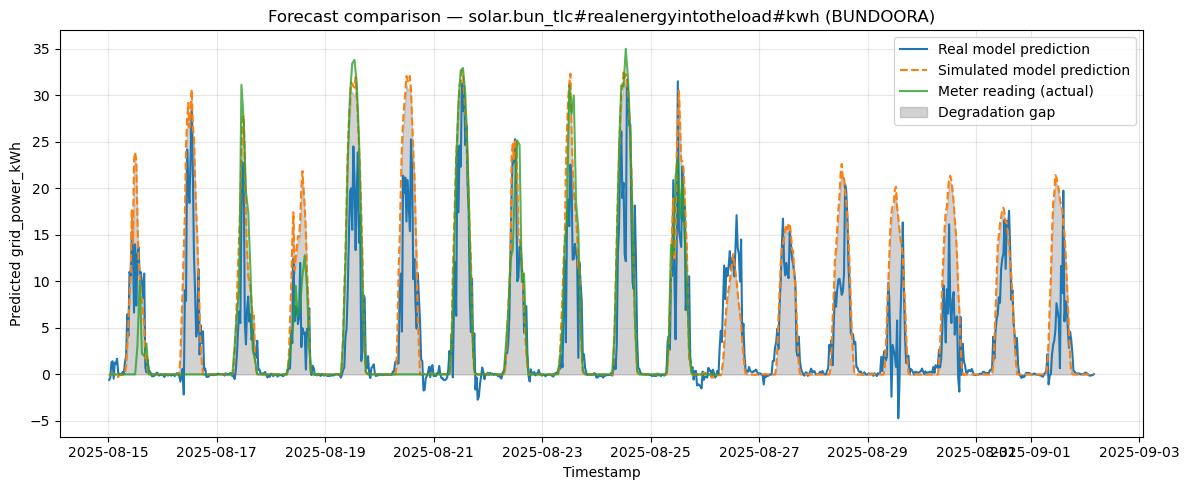

0.9703725093562656


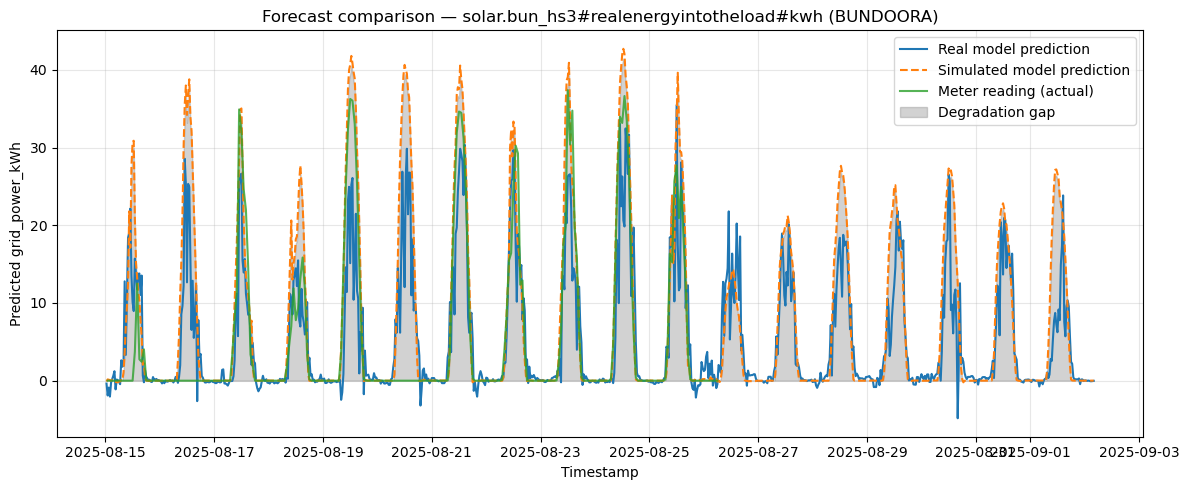

0.9703725093562656


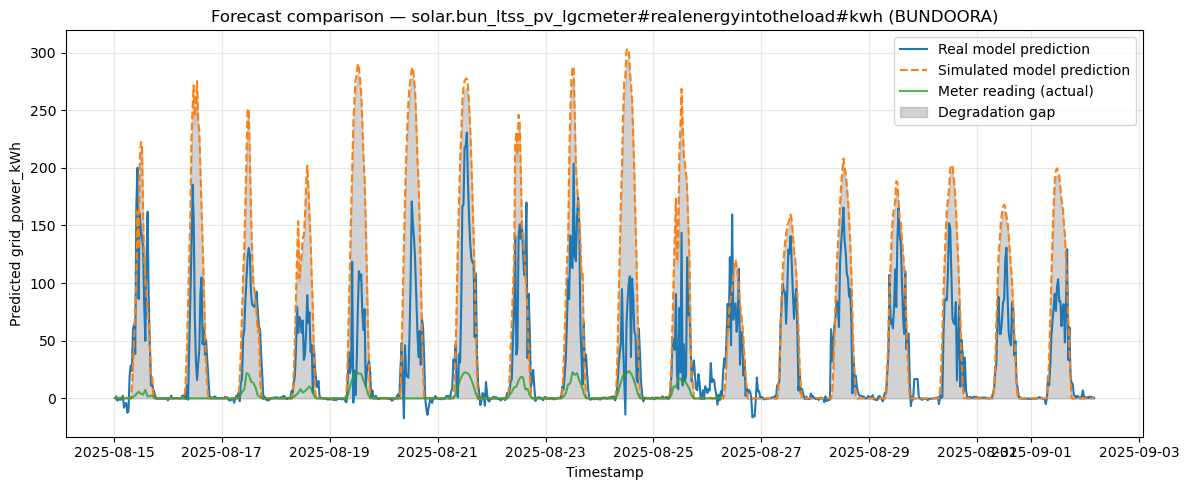

0.9703725093562656


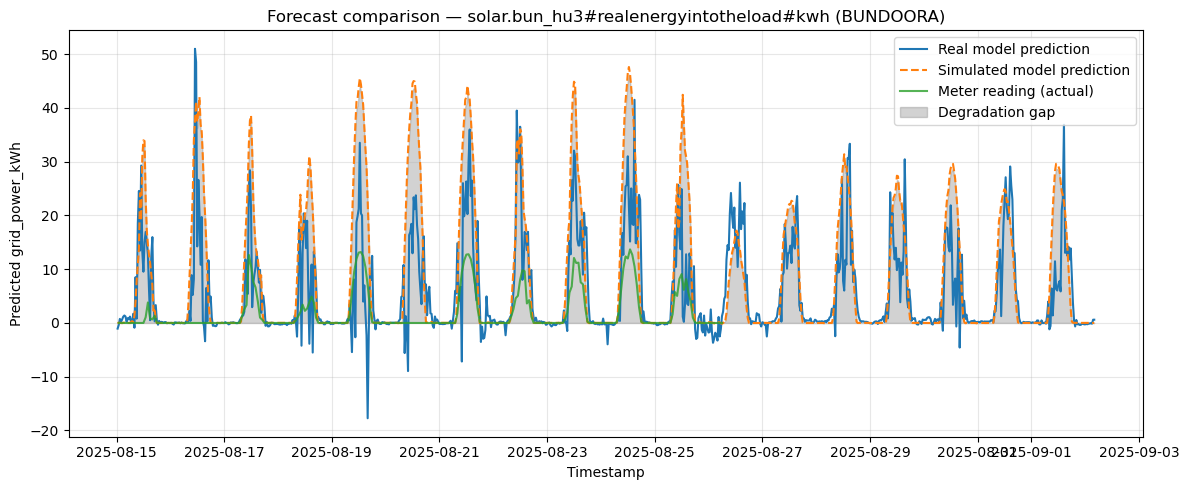

0.9703725093562656


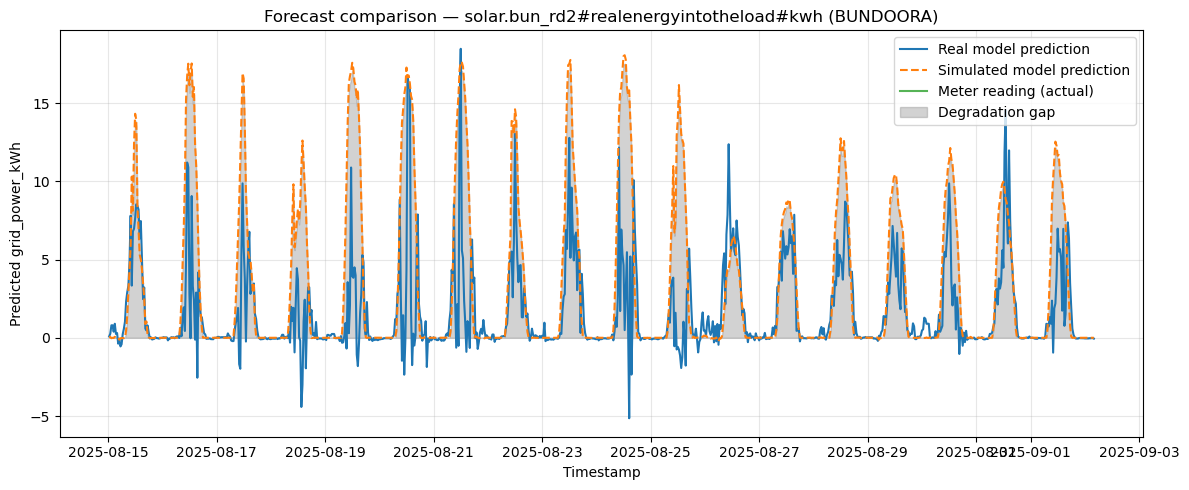

0.9703725093562656


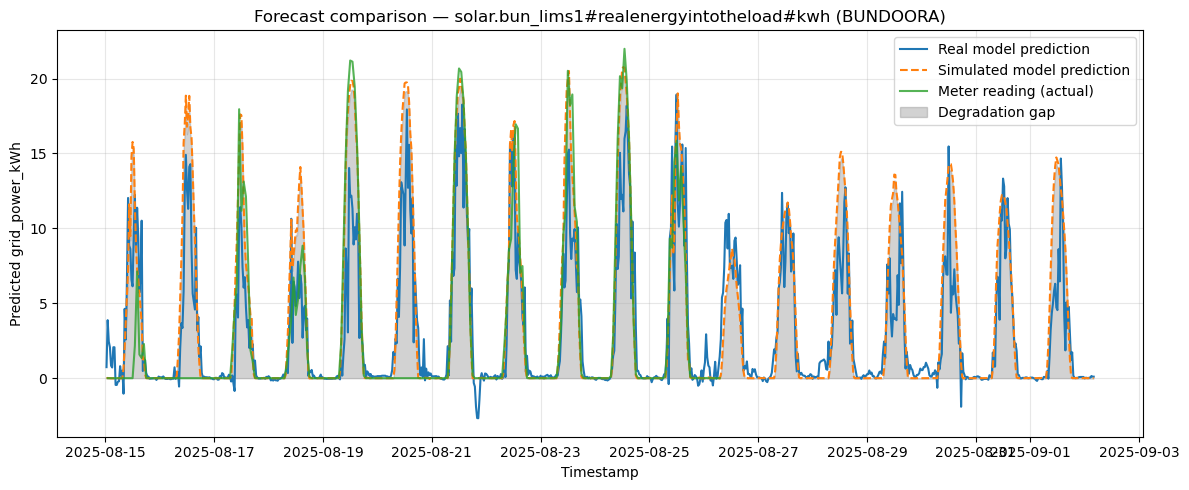

0.9703725093562656


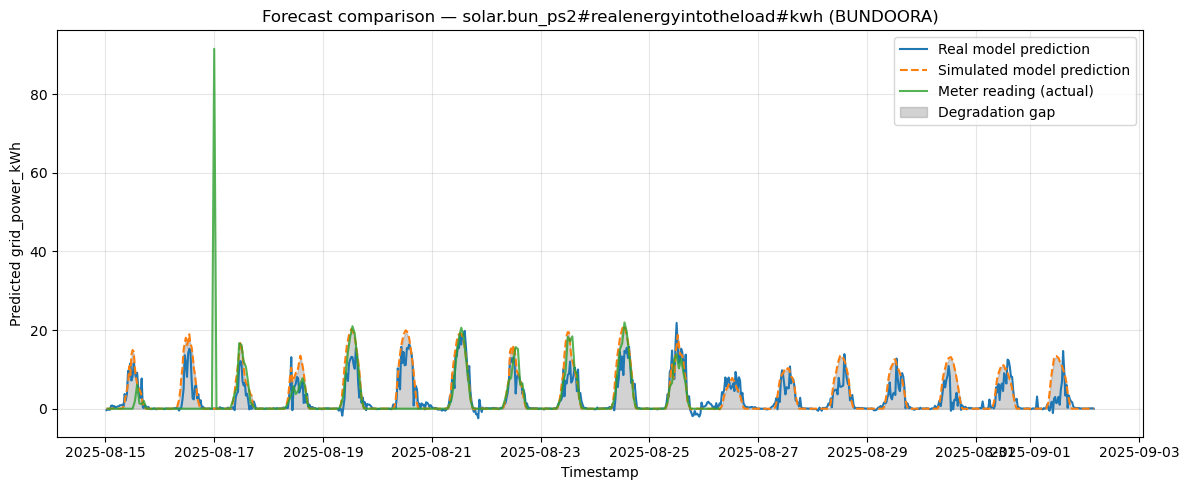

0.9703725093562656


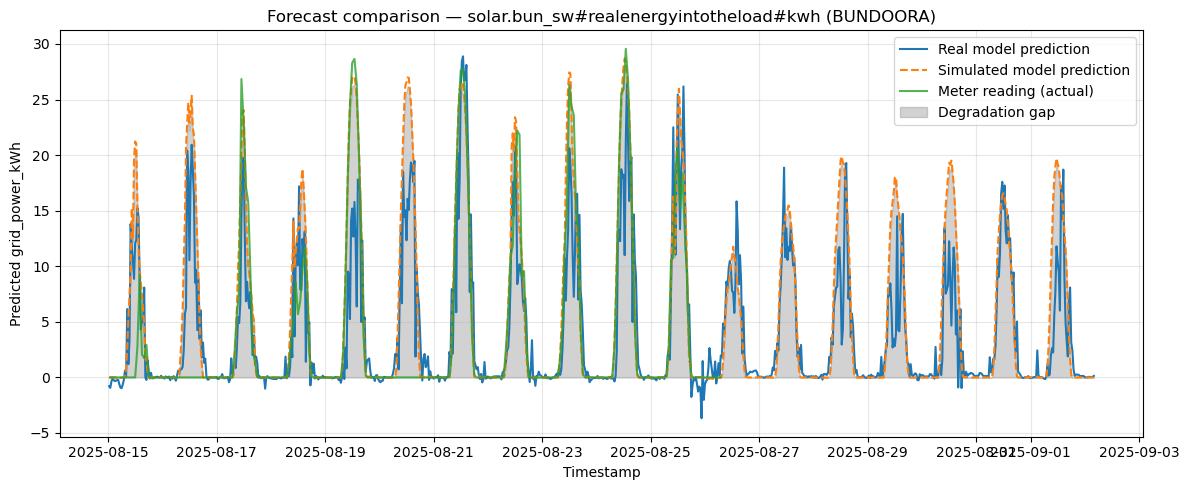

0.9703725093562656


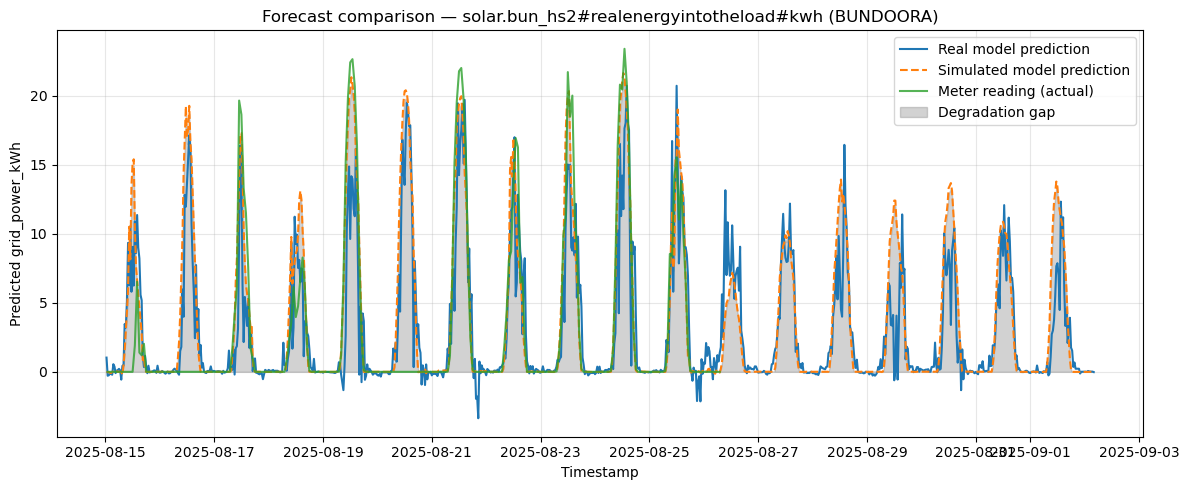

0.9703725093562656


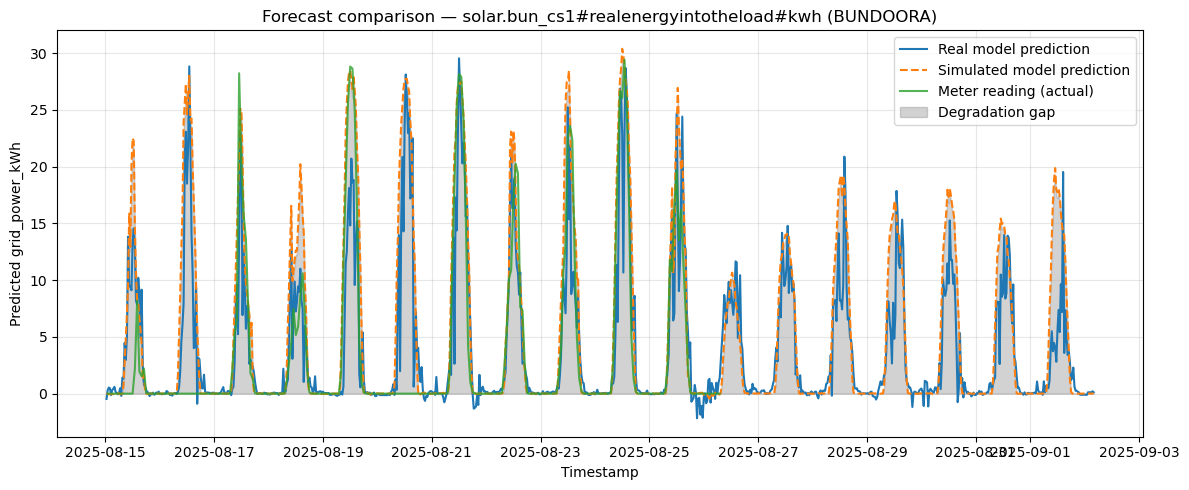

0.9703725093562656


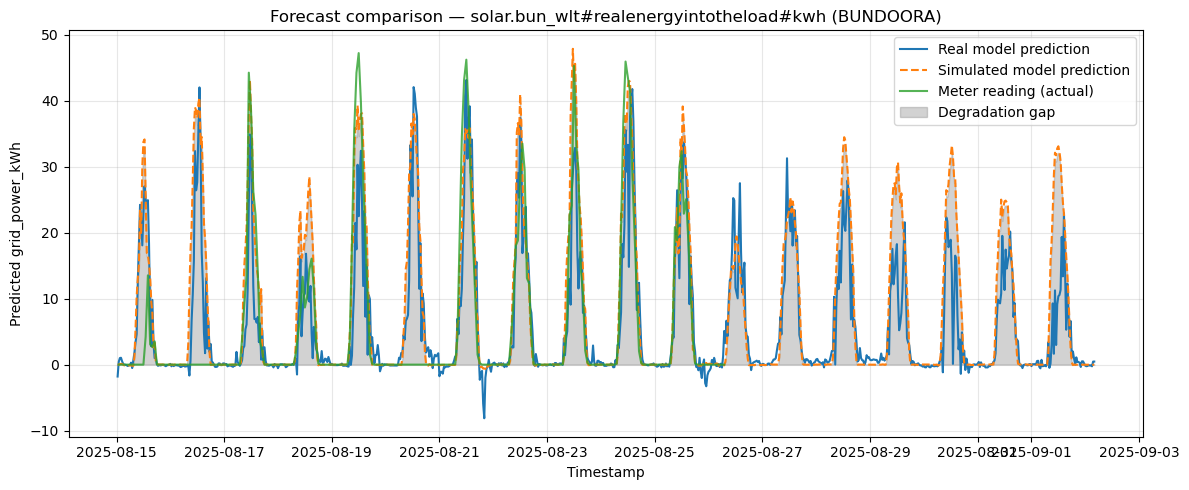

0.9703725093562656


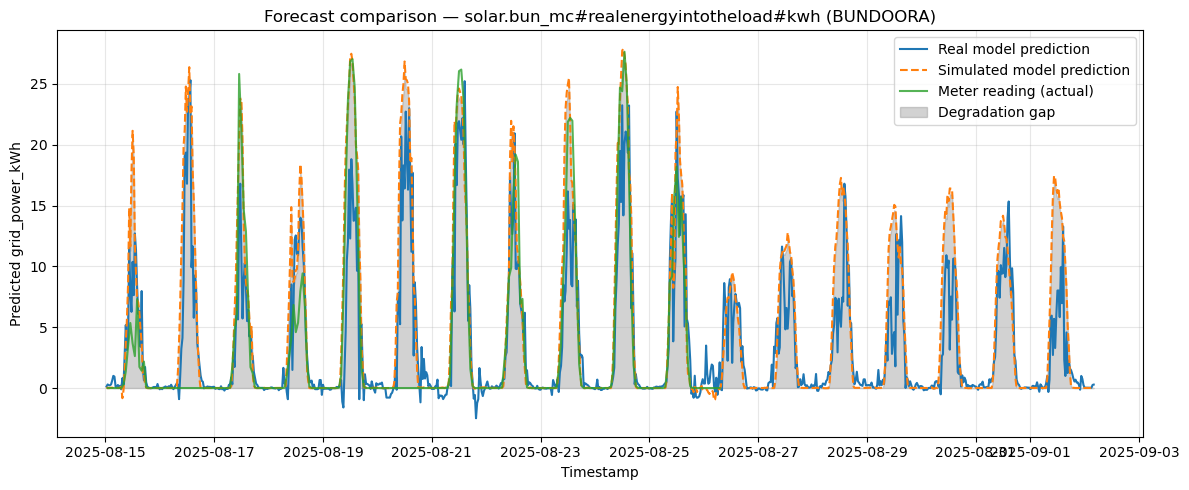

0.9703725093562656


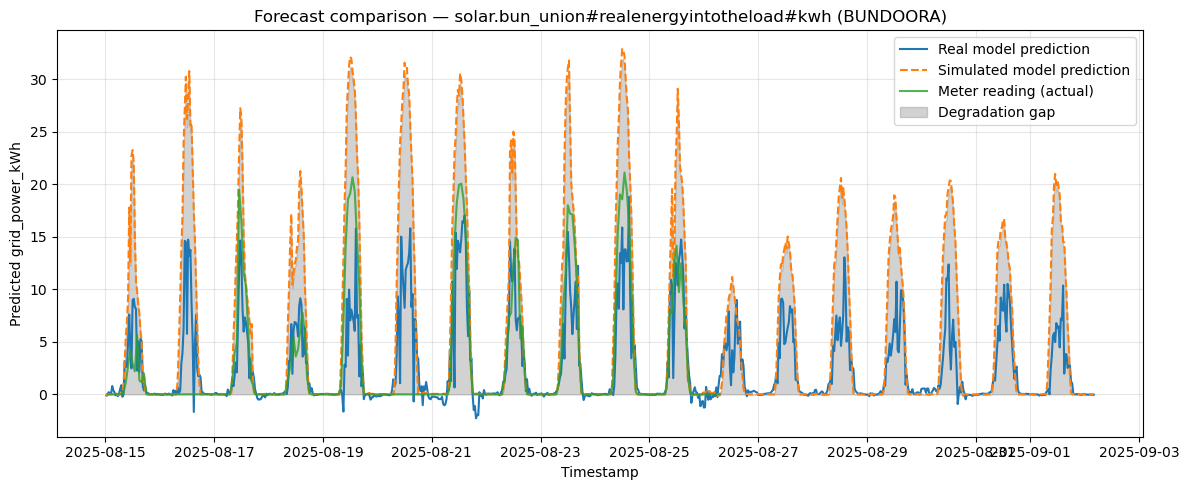

0.9703725093562656


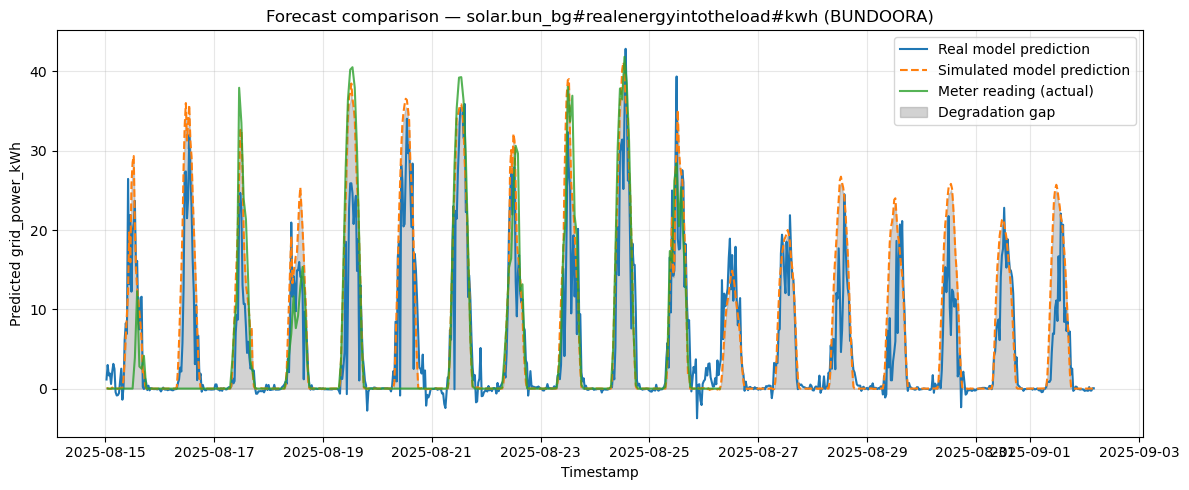

0.9703725093562656


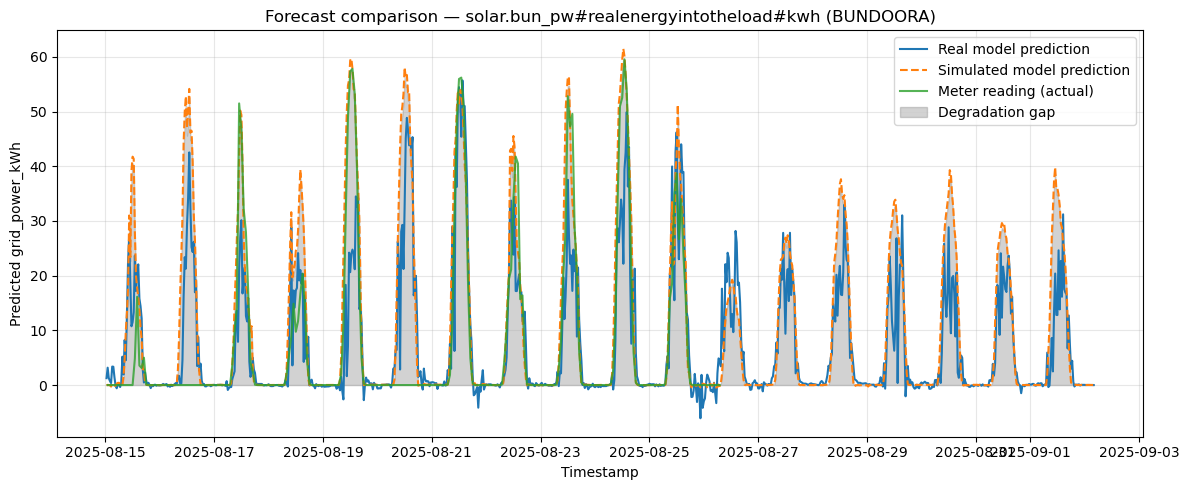

0.9703725093562656


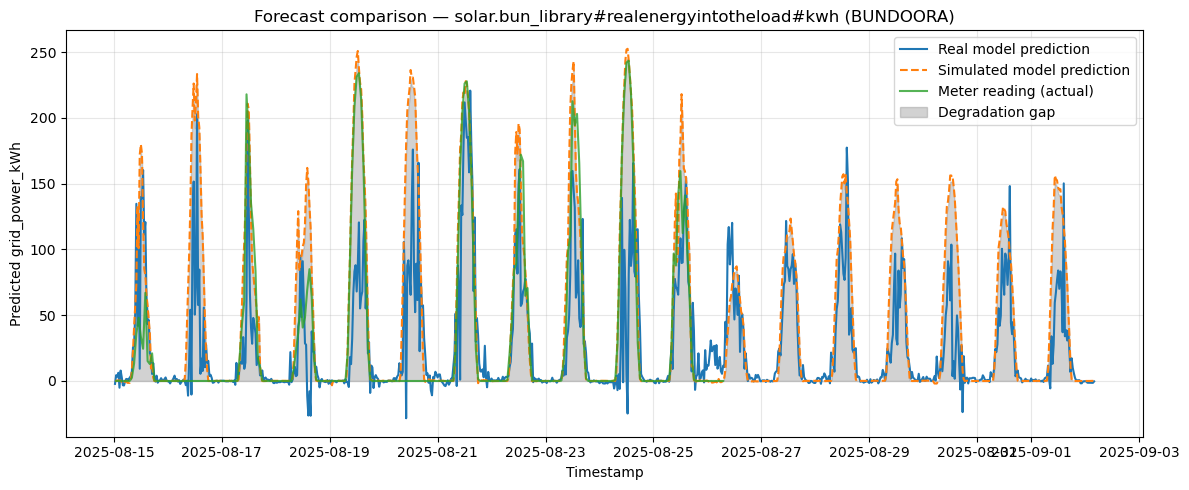

0.9703725093562656


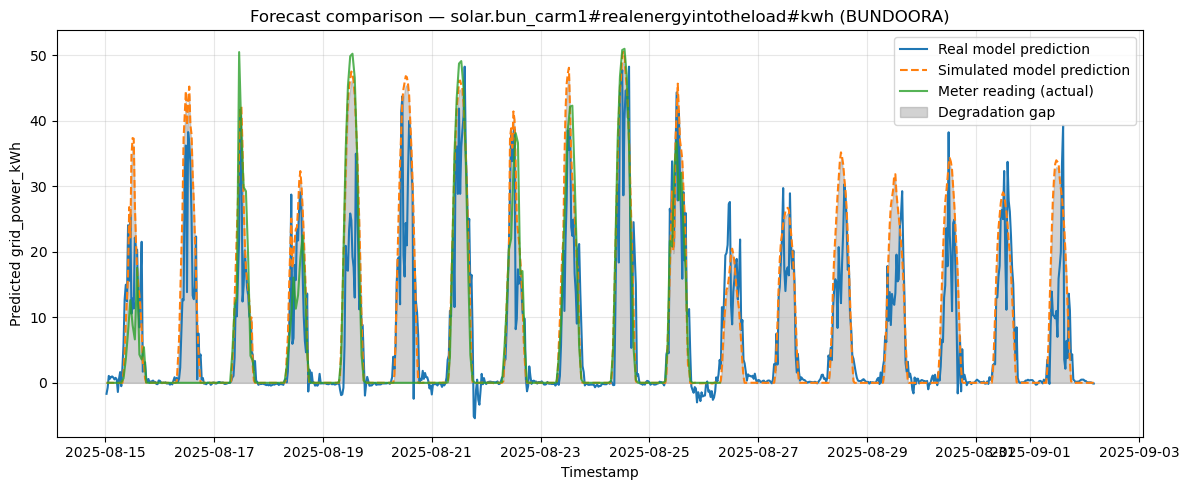

0.9703725093562656


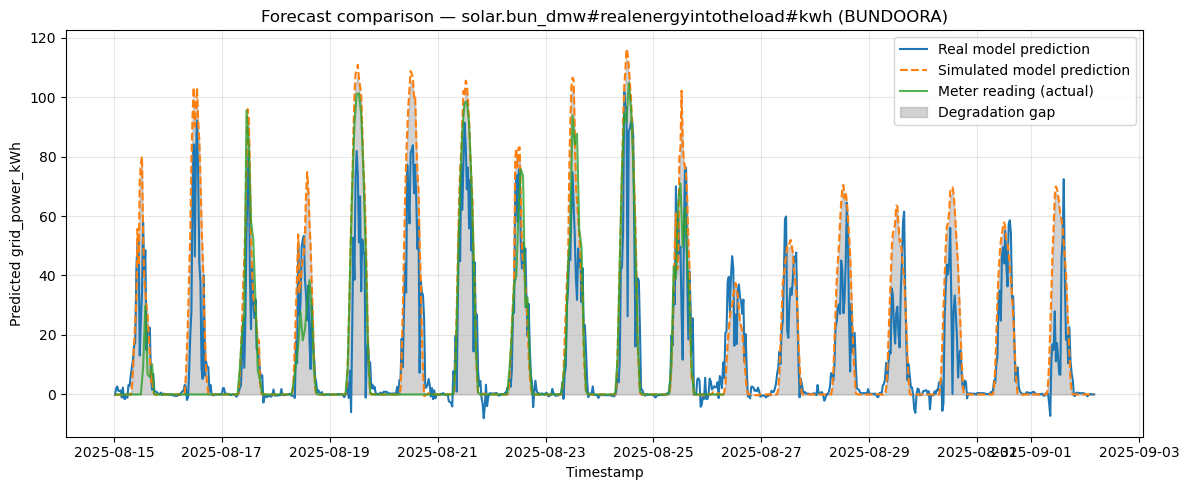

0.9703725093562656


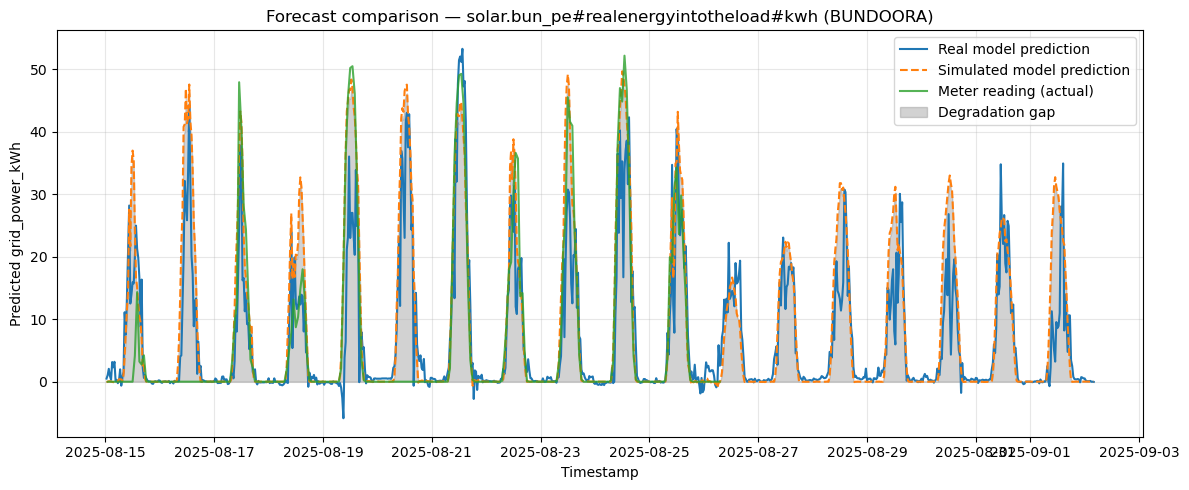

0.9703725093562656


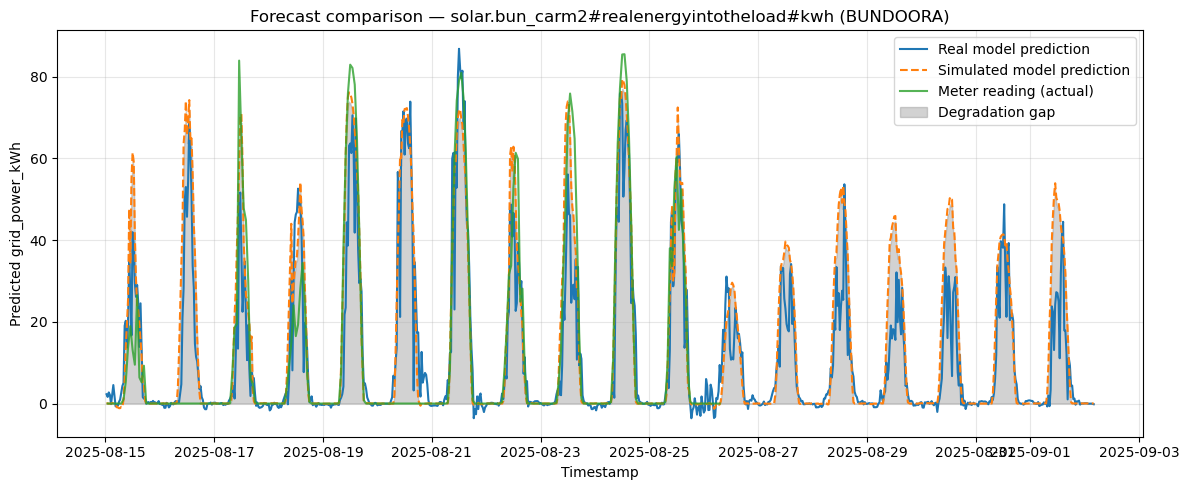

0.9703725093562656


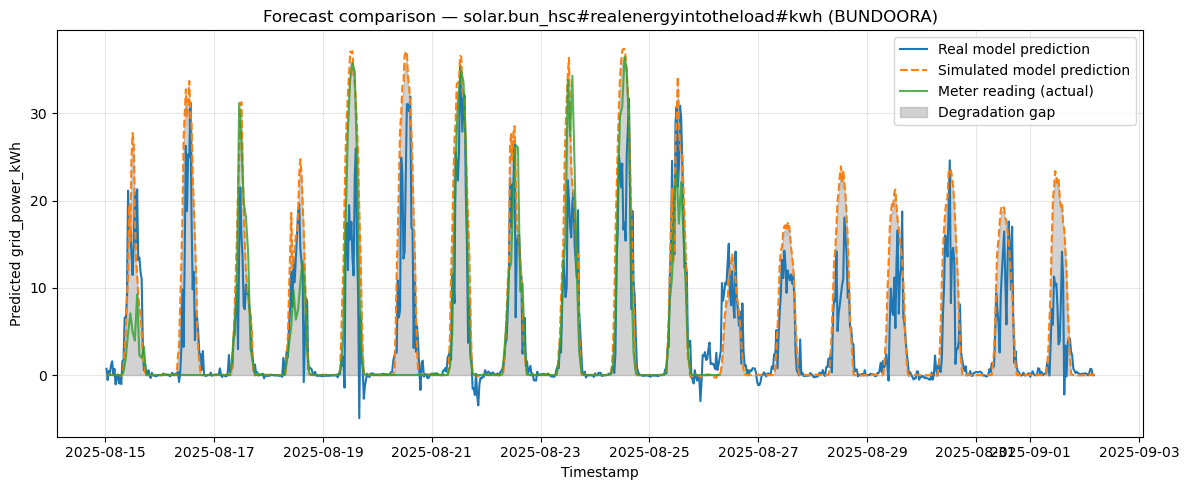

0.9703725093562656


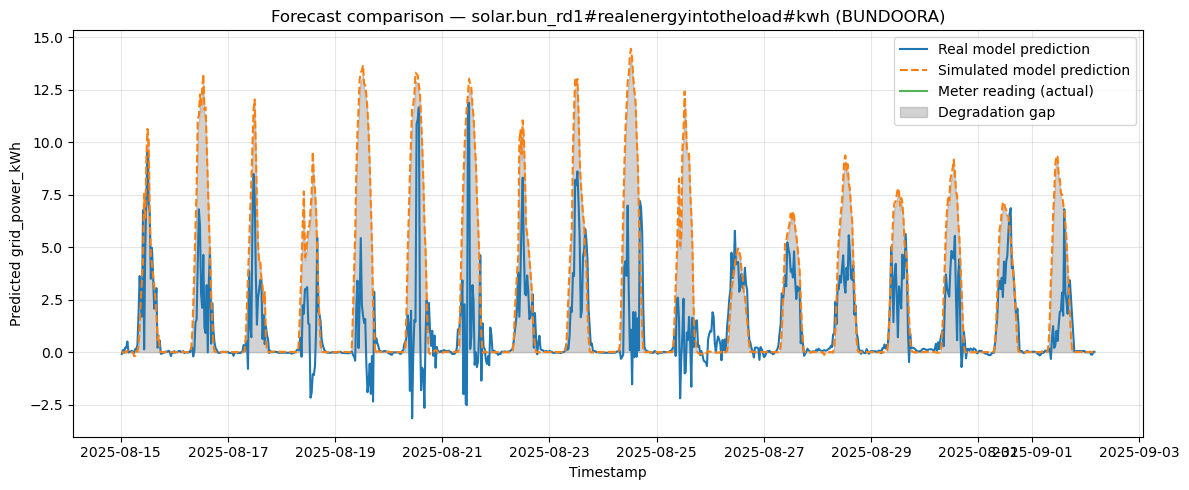

0.9703725093562656


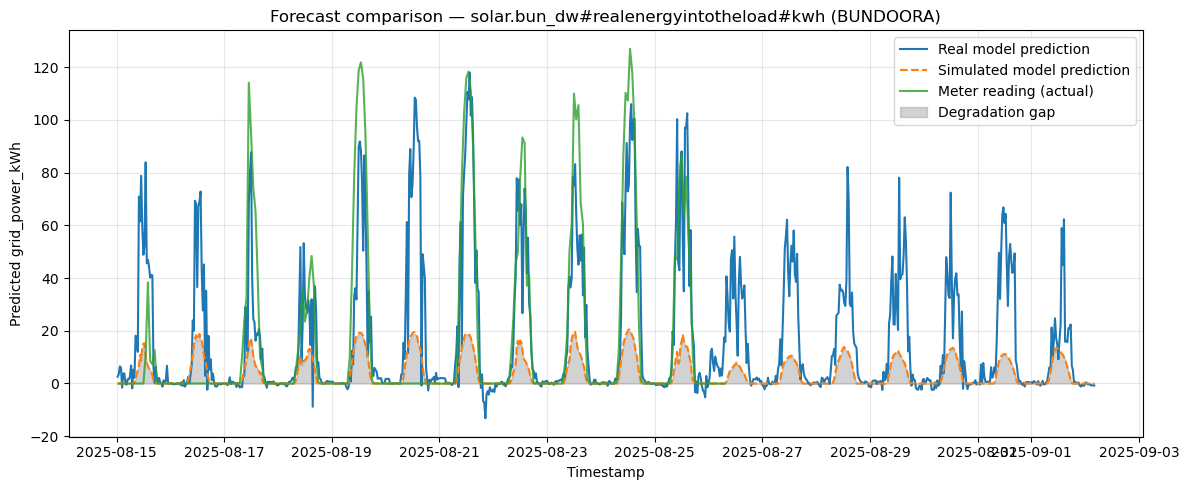

0.9703725093562656


PermissionError: [Errno 13] Permission denied: 'Results\\solar.bun_hs1#realenergyintotheload#kwh_series_new.csv'

In [55]:
for meter  in common:
    
    camp = get_campus(meter)
    if (camp in available_forecast): # and meter == "solar.bun_carm1#realenergyintotheload#kwh":
        temp_df = df[df['meter'] == meter]
        sol_df = solcast_forecast_df[solcast_forecast_df['campus'] == camp]
        features = ['global_horizontal_irradiance','air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith']
        target = 'grid_power_kWh'
        # Prepare the data
        X = sol_df[features].astype(float)

        xg_model_real = joblib.load('models/real_h/' + meter + '.pkl')
        xg_model_simulated = joblib.load('models/simulated/' + meter + '.pkl')

        y_real = xg_model_real.predict(X)
        y_sim  = xg_model_simulated.predict(X)

        ##################### Degredation part

        DEGRADE_RATE_PER_YEAR = 0.005
        FIRST_YEAR_DROP = 0.00 

        t_idx = pd.to_datetime(sol_df["timestamp"])
        t0 = t_idx.iloc[0]
        years_since_start = 6 #= (t_idx - t0).dt.total_seconds() / (365.25 * 24 * 3600.0)

        deg_factor = (1.0 - FIRST_YEAR_DROP) * np.power((1.0 - DEGRADE_RATE_PER_YEAR), years_since_start)
        y_sim_degraded = np.clip(y_sim * deg_factor, 0.0, None)

        print(deg_factor)




        act = final_df[final_df["meter"] == meter].copy()
        # sol_df["timestamp"]
        # print(list(sol_df["timestamp"])[0])
        act = act[(act["timestamp"] >= list(sol_df["timestamp"])[0])] 
        # print(act["meter_reading"].values)
        s_act = pd.Series(act["meter_reading"].values, index=act["timestamp"], name="Meter reading")
        # print(s_act["meter"])
        # Build series with timestamps as index (helps plotting)
        s_real = pd.Series(y_real, index=sol_df["timestamp"], name="Real model")
        s_sim  = pd.Series(y_sim,  index=sol_df["timestamp"], name="Simulated model")
        s_sim_deg = pd.Series(y_sim_degraded, index=t_idx, name="Simulated (degraded)")


        s_act_ = s_act.astype(float).where(s_act <= 200, 0.0)



        # ------------------ SAVE TO CSV ------------------
        # Align on the union of timestamps so nothing is lost
        all_idx = s_act.index.union(s_real.index).union(s_sim.index).union(s_sim_deg.index)
        df_out = pd.DataFrame({
            "Meter_reading": s_act.reindex(all_idx),
            "Real_model_prediction":  s_real.reindex(all_idx),
            "Simulated_model":        s_sim.reindex(all_idx),
            "Simulated_degraded":   s_sim_deg.reindex(all_idx),
        }, index=all_idx).sort_index()

        # Optional: add meter/campus columns
        df_out.index.name = "timestamp"
        df_out.insert(0, "meter", meter)
        df_out.insert(1, "campus", camp)

        # Drop duplicate timestamps if any
        df_out = df_out[~df_out.index.duplicated(keep="first")]

        csv_filename = f"{meter}_series_new.csv".replace("/", "-")
        df_out.to_csv(os.path.join("Results", csv_filename))
        # --------------------------------------------------

        # Plot
        plt.figure(figsize=(12, 5))
        plt.plot(s_real.index, s_real.values, label="Real model prediction")
        plt.plot(s_sim.index,  s_sim.values,  label="Simulated model prediction", linestyle="--")
        plt.plot(s_act.index,  s_act.values,  label="Meter reading (actual)", linewidth=1.5, alpha=0.8)
        plt.fill_between(s_sim_deg.index, 0, s_sim_deg.values,
                         color="gray", alpha=0.35, label="Degradation gap", zorder=1)


        plt.title(f"Forecast comparison — {meter} ({camp})")
        plt.xlabel("Timestamp")
        plt.ylabel("Predicted grid_power_kWh")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        filename = f"{meter}_{camp}_comparison.png"
        filepath = os.path.join("Results", filename)
        # plt.savefig(filepath, dpi=150)

        # plt.close()
        plt.show()

        

        

# solar.bun_ccr#realenergyintotheload#kwh.pkl

crystalline-silicon panels typically lose about 0.4–0.8% of output per year.
If your panels degrade ~0.5%/yr: output ≈ 97.5% of original (≈ 2.5% loss).
Many warranties assume a bigger first-year drop (e.g., ~2–3%) then ~0.4–0.7%/yr afterward, which lands around ~4–5% total loss by year 5

          timestamp  meter_reading                                     meter
2021-01-01 00:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 00:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 01:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 01:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 02:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 02:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 03:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 03:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 04:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 04:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 05:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 05:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh

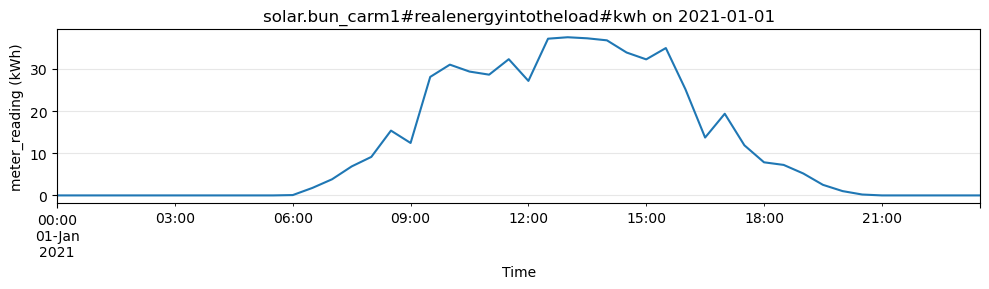

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load CSV ---
# Change the path if needed
df = pd.read_csv("data\SolarMeterReadings30min.csv", parse_dates=["timestamp"])

# --- Params ---
meter_key = "solar.bun_carm1#realenergyintotheload#kwh"     # case-insensitive partial match
day_str   = "2021-01-01"        # the day you want

# --- Filter to this meter ---
m_mask = df["meter"].str.lower().str.contains(meter_key.lower(), regex=False)

# --- Filter to that single day (00:00 to <00:00 next day) ---
d0 = pd.to_datetime(day_str)
d1 = d0 + pd.Timedelta(days=1)
day_df = (
    df.loc[m_mask & (df["timestamp"] >= d0) & (df["timestamp"] < d1),
           ["timestamp", "meter_reading", "meter"]]
    .sort_values("timestamp")
)

# --- See the data ---
print(day_df.to_string(index=False))

# --- Optional: quick plot ---
if not day_df.empty:
    ax = day_df.set_index("timestamp")["meter_reading"].plot(figsize=(10, 3))
    ax.set_title(f"{meter_key} on {d0.date()}")
    ax.set_xlabel("Time")
    ax.set_ylabel("meter_reading (kWh)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Helpful hint if nothing found
    avail = df.loc[m_mask, "timestamp"]
    if not avail.empty:
        print(f"No records on {d0.date()}. Available range for this meter: "
              f"{avail.min().date()} to {avail.max().date()}")
    else:
        print("No rows matching this meter id.")


In [34]:
day_df

,timestamp,meter_reading,meter
1517617,2021-01-01 00:00:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517618,2021-01-01 00:30:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517619,2021-01-01 01:00:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517620,2021-01-01 01:30:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517621,2021-01-01 02:00:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517622,2021-01-01 02:30:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517623,2021-01-01 03:00:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517624,2021-01-01 03:30:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517625,2021-01-01 04:00:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh
1517626,2021-01-01 04:30:00,0.000000,solar.bun_carm1#realenergyintotheload#kwh


## Predict using XGBoost

In [ ]:
# Create an SQLAlchemy engine
engine = create_engine(connection_url)
all_temp_dfs = []

first = True
for i in range(len(meters)):
    meter = meters[i]
    camp = get_campus(meter)

    temp_df = df[df['meter'] == meter]
    if temp_df.empty:
        print("dataset is empty")
    else:
        temp_df.set_index('timestamp', inplace=True)
        temp_df = temp_df.resample('H').agg({
        'meter_reading': 'sum',  # Summing up for 'value_sum'
        })
        temp_df.reset_index(inplace=True)

        sol_df = solcast_df[solcast_df['campus'] == camp]
        temp_df = pd.merge(temp_df, sol_df, on='timestamp', how='inner')
        # print(temp_df)
        # print(temp_df)
        # break
        temp_df.set_index('timestamp', inplace=True)
        temp_df = temp_df.resample('H').agg({
        'meter_reading': 'sum',  # Summing up for 'value_sum'
        'global_horizontal_irradiance': 'mean',  # Summing up for 'value_sum'
        'air_temp': 'mean',
        'cloud_opacity': 'mean',
        'relative_humidity': 'mean',
        'dewpoint_temp': 'mean',
        'wind_speed_10m': 'mean',
        'zenith': 'mean'
        })

        temp_df.reset_index(inplace=True)

        print(f"Processing {meter}")

        # try:
        model_name = meter + '.pkl'
        filepath = os.path.join('models/simulated', model_name)
        xgb_model = joblib.load(filepath)

        features = ['global_horizontal_irradiance','air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith']
        target = 'meter_reading'

        # Prepare the data
        X = temp_df[features].astype(float)
        y = temp_df[target].astype(float)

        xgb_predictions = xgb_model.predict(X)   # ---------------------------

        # Evaluate the models___
        xgb_rmse = np.sqrt(mean_squared_error(y, xgb_predictions))

        print(f'Test RMSE: {xgb_rmse}')

        temp_df['baseline'] = xgb_predictions       # prediceted Value

        # temp df contains data of hourly. Following step accumulate that data for daily and filter sum amount of data.



        temp_df_cp = temp_df.copy()

        temp_df.set_index('timestamp', inplace=True)
        temp_df = temp_df.resample('D').agg({
        'meter_reading': 'sum',  # Summing up for 'value_sum'
        'global_horizontal_irradiance': 'mean',
        'baseline': 'sum',  # Summing up for 'value_sum'
        })
        temp_df.reset_index(inplace=True)
        temp_df = temp_df.round(4)
        temp_df['meter'] = [meter] * len(temp_df)

        temp_df_cp['meter'] = [meter] * len(temp_df_cp)
        temp_df_cp.reset_index(inplace=True)
        all_temp_dfs.append(temp_df_cp.copy())

        if(first):
            res_df = temp_df.copy()
            first = False
        else:
            res_df = pd.concat([res_df, temp_df], ignore_index=True)
        # except:
        #     print("Failed")
        acc_df.loc[acc_df['Meter']==meter, 'TEST NEW RMSE'] = xgb_rmse
        print("")
# acc_df.to_csv('data/model_accuracy.csv', index=False)
all_meters_dfs = pd.concat(all_temp_dfs, ignore_index=True)
all_meters_dfs.to_csv('data/baseline_hourly_new.csv', index=False)
# Close the engine connection
engine.dispose()

dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
Processing solar.bun_dmw#realenergyintotheload#kwh
Test RMSE: 47.79589345937992

dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty
dataset is empty


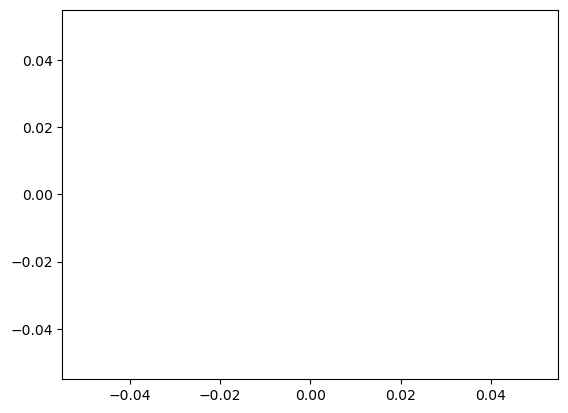

In [83]:
temp = res_df[res_df['meter'] == 'solar.bun_library#realenergyintotheload#kwh']
plt.plot(temp['baseline'].to_list())
plt.plot(temp['meter_reading'].to_list())

In [84]:
 pd.DataFrame({'Timestamp': res_df['timestamp'].to_list(),
              'Actual (kWh)': res_df['meter_reading'].to_list(),
              'Baseline (kWh)': res_df['baseline'].to_list(),
              'GHI Solcast (W/m^2)': res_df['global_horizontal_irradiance'].to_list(),
              'Meter': res_df['meter'].to_list()
             }).to_csv('data/baseline_daily_new.csv', index=False)

In [85]:
------------------------------------------------------------------------------------------------------------------------------------

SyntaxError: invalid syntax (4183810212.py, line 1)

In [ ]:
df1 = pd.read_csv('data/baseline_daily_new.csv')
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])

df2 = pd.read_csv('data/baseline_daily_sim.csv')
df2['Timestamp'] = pd.to_datetime(df2['Timestamp'])

for m in meters:
    temp_df1 = df1[df1['Meter'] == m]
    temp_df2 = df2[df2['Meter'] == m]

    
    df1 = df1[df1['Timestamp'] >= '2024-01-01']


FileNotFoundError: [Errno 2] No such file or directory: 'data/baseline_daily_sim.csv'

In [ ]:
df1 = pd.read_csv('data/baseline_daily_new.csv')
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])
latest_indices = df1.groupby('Meter')['Timestamp'].idxmax()
df1.drop(latest_indices, inplace=True)

df2 = pd.read_csv('dta/baseline_daily_sim.csv')
df2['Timestamp'] = pd.to_datetime(df2['Timestamp'])
df2 = df2[df2['Timestamp'] >= '2024-08-20']

df_combined = pd.concat([df1, df2], ignore_index=True)
df_combined.to_csv('dta/baseline_with_sim.csv')

In [ ]:
df_combined

In [ ]:
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])

# Get the index of the latest timestamp for each 'Meter'
latest_indices = df1.groupby('Meter')['Timestamp'].idxmax()

# Select rows based on those indices

df1.drop(latest_indices, inplace=True)
latest_indices = df1.groupby('Meter')['Timestamp'].idxmax()
df1.loc[latest_indices]

,Timestamp,Actual (kWh),Baseline (kWh),GHI Solcast (W/m^2),Meter
47255,2024-08-19,219.2656,215.533096,156.2500,solar.bun_bg#realenergyintotheload#kwh
13501,2024-08-19,274.4844,284.169312,156.2500,solar.bun_carm1#realenergyintotheload#kwh
23630,2024-08-19,472.4062,432.402710,156.2500,solar.bun_carm2#realenergyintotheload#kwh
38820,2024-08-19,139.5000,158.753006,156.2500,solar.bun_cs1#realenergyintotheload#kwh
5066,2024-08-19,576.9062,572.958008,156.2500,solar.bun_dmw#realenergyintotheload#kwh
43881,2024-08-19,655.1250,111.081902,156.2500,solar.bun_dw#realenergyintotheload#kwh
8440,2024-08-19,255.4531,261.404205,156.2500,solar.bun_hs1#realenergyintotheload#kwh
10127,2024-08-19,115.6406,107.993103,156.2500,solar.bun_hs2#realenergyintotheload#kwh
21943,2024-08-19,205.1719,221.702393,156.2500,solar.bun_hs3#realenergyintotheload#kwh
37133,2024-08-19,175.1562,195.907898,156.2500,solar.bun_hsc#realenergyintotheload#kwh


In [ ]:
df2[df2['Timestamp'] >= '2024-08-20']

,Timestamp,Actual (kWh),Baseline (kWh),GHI Solcast (W/m^2),Meter
232,2024-08-20,0,123.901398,121.6125,solar.bun_sw#realenergyintotheload#kwh
233,2024-08-21,0,57.588902,58.6854,solar.bun_sw#realenergyintotheload#kwh
234,2024-08-22,0,185.888596,181.4584,solar.bun_sw#realenergyintotheload#kwh
235,2024-08-23,0,172.726807,169.4452,solar.bun_sw#realenergyintotheload#kwh
236,2024-08-24,0,183.767593,179.9368,solar.bun_sw#realenergyintotheload#kwh
...,...,...,...,...,...
10975,2024-12-27,0,319.914612,234.4042,solar.bun_bg#realenergyintotheload#kwh
10976,2024-12-28,0,91.397301,70.2292,solar.bun_bg#realenergyintotheload#kwh
10977,2024-12-29,0,404.654602,298.5944,solar.bun_bg#realenergyintotheload#kwh
10978,2024-12-30,0,391.507690,289.6764,solar.bun_bg#realenergyintotheload#kwh


In [ ]:
df_combined

,Timestamp,Actual (kWh),Baseline (kWh),GHI Solcast (W/m^2),Meter
0,2020-01-08,0.0,295.554413,443.4375,solar.bun_sw#realenergyintotheload#kwh
1,2020-01-09,0.0,341.279694,346.7917,solar.bun_sw#realenergyintotheload#kwh
2,2020-01-10,0.0,144.357697,142.1250,solar.bun_sw#realenergyintotheload#kwh
3,2020-01-11,0.0,191.430099,190.0000,solar.bun_sw#realenergyintotheload#kwh
4,2020-01-12,0.0,288.009796,285.0833,solar.bun_sw#realenergyintotheload#kwh
...,...,...,...,...,...
58232,2024-12-27,NaN,NaN,NaN,NaN
58233,2024-12-28,NaN,NaN,NaN,NaN
58234,2024-12-29,NaN,NaN,NaN,NaN
58235,2024-12-30,NaN,NaN,NaN,NaN


In [ ]:
# Solar Baseline for year ahead

In [ ]:
# Create an SQLAlchemy engine
engine = create_engine(connection_url)
    
first = True
for meter in meters:
    print(f"Processing {meter}")
    
    try:
        # Use the engine to execute a query and load the result set into a DataFrame
        query = f"SELECT *, [grid_power] / 1000 AS grid_power_kWh FROM [Leap].[dbo].[SolarSiteSimulation] WHERE meter = '{meter}' ORDER BY timestamp"
        sim_df = pd.read_sql_query(query, engine)

        sim_df = sim_df[:len(sim_df)//2]
        sim_df['timestamp'] = sim_df['timestamp'].apply(lambda x: x.replace(year=2024))
        print(sim_df.head(10))
        model_name = meter + '.pkl'
        filepath = os.path.join('models/new', model_name)
        xgb_model = joblib.load(filepath)

        # Select features and target variable
        features = ['global_horizontal_irradiance']
        target = 'grid_power_kWh'

        # Prepare the data
        X = sim_df[features].astype(float)
        y = sim_df[target].astype(float)

        xgb_predictions = xgb_model.predict(X)

        # Evaluate the models___
        xgb_rmse = np.sqrt(mean_squared_error(y, xgb_predictions))

        print(f'Test RMSE: {xgb_rmse}')

        sim_df['baseline'] = xgb_predictions

        sim_df.set_index('timestamp', inplace=True)
        sim_df = sim_df.resample('D').agg({
        'global_horizontal_irradiance': 'mean',
        'baseline': 'sum',  # Summing up for 'value_sum'
        })
        sim_df.reset_index(inplace=True)

        sim_df = sim_df.round(4)
        sim_df['meter'] = [meter] * len(sim_df)
        sim_df['meter_reading'] = [0] * len(sim_df)

        if(first):
            res_df = sim_df.copy()
            first = False
        else:
            res_df = pd.concat([res_df, sim_df], ignore_index=True)
    except:
        print("Failed")
        
    print("")
# Close the engine connection
engine.dispose()

Processing solar.bun_sw#realenergyintotheload#kwh
Test RMSE: 0.5454388624151609

Processing solar.bun_ltss_pv_lgcmeter#realenergyintotheload#kwh
Test RMSE: 4.212827035899406

Processing solar.bun_dmw#realenergyintotheload#kwh
Test RMSE: 2.930582740105505

Processing solar.bun_wlt#realenergyintotheload#kwh
Test RMSE: 3.2888890829773985

Processing solar.bun_hs1#realenergyintotheload#kwh
Test RMSE: 1.2175213649216885

Processing solar.bun_hs2#realenergyintotheload#kwh
Test RMSE: 0.579245192647545

Processing solar.bun_lims1#realenergyintotheload#kwh
Test RMSE: 0.3639964058359938

Processing solar.bun_carm1#realenergyintotheload#kwh
Test RMSE: 0.773044531688831

Processing solar.bun_mb#realenergyintotheload#kwh
Test RMSE: 1.7303280653180928

Processing solar.shepparton#realenergyintotheload#kwh
Test RMSE: 1.374830421151646

Processing solar.bun_ss#realenergyintotheload#kwh
Test RMSE: 1.5107742220318894

Processing solar.bun_union#realenergyintotheload#kwh
Test RMSE: 0.9910393334689752

Pr

In [ ]:
pd.DataFrame({'Timestamp': res_df['timestamp'].to_list(), 
              'Actual (kWh)': res_df['meter_reading'].to_list(),
              'Baseline (kWh)': res_df['baseline'].to_list(),
              'GHI Solcast (W/m^2)': res_df['global_horizontal_irradiance'].to_list(),
              'Meter': res_df['meter'].to_list()
             }).to_csv('data/baseline_daily_sim.csv', index=False)

## _____________________________________________________________________________________  MY DEV  _____________________________________________________________________________

In [ ]:
df_30 = pd.read_csv("data/SolarMeterReadings30min.csv")
sol_real = pd.read_csv("data/solcast_real.csv")
sol_pred = pd.read_csv("data/solcast_pred.csv")
sol_pred = sol_pred[sol_pred["timestamp"] > list(df_30["timestamp"])[-1]]
meters = pd.unique(df_30["meter"])


In [ ]:


for meter in meters:

    

['solar.albury-wodonga_admin#realenergyintotheload#kwh'
 'solar.albury-wodonga_carport#realenergyintotheload#kwh'
 'solar.albury-wodonga_health#realenergyintotheload#kwh'
 'solar.albury-wodonga_library#realenergyintotheload#kwh'
 'solar.albury-wodonga_mh1#realenergyintotheload#kwh'
 'solar.albury-wodonga_mh2#realenergyintotheload#kwh'
 'solar.bendigo_as2_carpark#realenergyintotheload#kwh'
 'solar.bendigo_as2_hhs1-2#realenergyintotheload#kwh'
 'solar.bendigo_as2_ssc_roof#realenergyintotheload#kwh'
 'solar.bendigo_hillside_a1#realenergyintotheload#kwh'
 'solar.bendigo_hillside_a2#realenergyintotheload#kwh'
 'solar.bendigo_hillside_a3#realenergyintotheload#kwh'
 'solar.bendigo_hillside_a4-6#realenergyintotheload#kwh'
 'solar.bendigo_lsu_carpark#realenergyintotheload#kwh'
 'solar.bendigo_lsu_ed_roof#realenergyintotheload#kwh'
 'solar.bendigo_lu_business#realenergyintotheload#kwh'
 'solar.bendigo_lu_visual_arts#realenergyintotheload#kwh'
 'solar.bun_bg#realenergyintotheload#kwh'
 'solar.bun

In [ ]:
sol_pred

,Unnamed: 0,air_temp,albedo,azimuth,cloud_opacity,dewpoint_temp,dhi,dni,ghi,precipitable_water,...,snow_water_equivalent,snow_soiling_rooftop,snow_soiling_ground,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,zenith,timestamp,campus
328,336,8,0.17,-36,0,1.4,51,930,551,5.7,...,0.0,0,0,128,124,1.9,1.6,58,2025-08-18 10:30:00,WODONGA
329,0,9,0.14,-37,56,2.4,218,0,218,8.7,...,0.0,0,0,165,165,2.5,1.4,60,2025-08-18 10:30:00,BUNDOORA
330,337,10,0.17,-28,0,0.8,53,946,605,5.8,...,0.0,0,0,134,133,1.8,1.5,54,2025-08-18 11:00:00,WODONGA
331,1,10,0.14,-29,56,1.9,243,0,243,8.6,...,0.0,0,0,166,165,3.5,2.0,56,2025-08-18 11:00:00,BUNDOORA
332,2,11,0.14,-21,55,1.4,268,0,268,8.5,...,0.0,0,0,168,169,4.2,2.4,54,2025-08-18 11:30:00,BUNDOORA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,333,11,0.14,43,40,7.1,227,136,298,15.8,...,0.0,0,0,267,267,7.8,4.1,59,2025-08-28 15:00:00,BUNDOORA
1308,670,9,0.17,52,44,7.6,201,80,237,17.7,...,0.0,0,0,284,289,3.6,1.7,63,2025-08-28 15:30:00,WODONGA
1309,334,11,0.14,49,41,7.1,197,121,252,15.4,...,0.0,0,0,268,269,7.5,3.9,63,2025-08-28 15:30:00,BUNDOORA
1310,335,10,0.14,56,43,7.1,164,91,199,14.9,...,0.0,0,0,269,271,7.2,3.6,68,2025-08-28 16:00:00,BUNDOORA
